# Week 4 - Baseline Model

Train a first-pass Linear Regression model using the Week 3 cleaned modeling table. The goal is to set a simple R² benchmark before trying stronger models.

## Setup

The Week 3 CSV already contains cleaned numeric features plus the time-based `train`/`test` split. This notebook starts from that file so the baseline model is consistent with the preprocessing workflow.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CLEANED_PATH = Path("data/week3_cleaned.csv")

if not CLEANED_PATH.exists():
    raise FileNotFoundError(
        "Missing data/week3_cleaned.csv. Run 02_preprocessing.ipynb before this notebook."
    )

pd.options.display.float_format = "{:,.4f}".format

In [2]:
df = pd.read_csv(CLEANED_PATH)

print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns):,}")

display(df["split"].value_counts().rename("rows").to_frame())
display(df.groupby("split")["CloseMonth"].agg(["min", "max", "nunique"]))

Rows: 393,502
Columns: 45


,rows
split,
train,381478
test,12024


,min,max,nunique
split,,,
test,2026-05,2026-05,1
train,2023-05,2026-04,36


## Prepare train/test matrices

`ClosePrice` is the target. Identifier/date columns and the split label are excluded from the feature matrix.

In [3]:
ID_COLS = ["RecordId", "CloseDate", "CloseMonth", "ClosePrice", "split"]
feature_cols = [col for col in df.columns if col not in ID_COLS]

train = df[df["split"].eq("train")].copy()
test = df[df["split"].eq("test")].copy()

X_train = train[feature_cols].to_numpy(dtype="float64")
y_train = train["ClosePrice"].to_numpy(dtype="float64")

X_test = test[feature_cols].to_numpy(dtype="float64")
y_test = test["ClosePrice"].to_numpy(dtype="float64")

summary = pd.Series(
    {
        "training_rows": len(train),
        "test_rows": len(test),
        "feature_count": len(feature_cols),
        "train_start_month": train["CloseMonth"].min(),
        "train_end_month": train["CloseMonth"].max(),
        "test_month": test["CloseMonth"].unique()[0],
        "feature_missing_values": int(train[feature_cols].isna().sum().sum() + test[feature_cols].isna().sum().sum()),
    }
)

display(summary.to_frame("value"))

,value
training_rows,381478
test_rows,12024
feature_count,40
train_start_month,2023-05
train_end_month,2026-04
test_month,2026-05
feature_missing_values,0


## Train Linear Regression

`scikit-learn` is not installed in this local environment, so this uses NumPy ordinary least squares through `np.linalg.lstsq`. This is equivalent to an unregularized Linear Regression model with an intercept.

In [4]:
def add_intercept(X):
    """Add an intercept column for ordinary least squares."""
    return np.column_stack([np.ones(len(X)), X])


X_train_design = add_intercept(X_train)
X_test_design = add_intercept(X_test)

coefficients, residuals, rank, singular_values = np.linalg.lstsq(
    X_train_design,
    y_train,
    rcond=None,
)

test_predictions = X_test_design @ coefficients

print(f"Model rank: {rank:,}")
print(f"Predictions created for {len(test_predictions):,} test rows")

Model rank: 38
Predictions created for 12,024 test rows


## Evaluate baseline on the test set

The assignment asks for R², and a few extra error metrics are included to make the baseline easier to interpret.

In [5]:
def r2_score(y_true, y_pred):
    residual_sum_of_squares = np.sum((y_true - y_pred) ** 2)
    total_sum_of_squares = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - residual_sum_of_squares / total_sum_of_squares


def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true))


def median_absolute_percentage_error(y_true, y_pred):
    return np.median(np.abs((y_true - y_pred) / y_true))


baseline_results = pd.DataFrame(
    [
        {
            "model": "Linear Regression (OLS)",
            "target": "ClosePrice",
            "test_month": test["CloseMonth"].unique()[0],
            "train_rows": len(train),
            "test_rows": len(test),
            "features": len(feature_cols),
            "r2": r2_score(y_test, test_predictions),
            "mae": np.mean(np.abs(y_test - test_predictions)),
            "rmse": np.sqrt(np.mean((y_test - test_predictions) ** 2)),
            "mape": mean_absolute_percentage_error(y_test, test_predictions),
            "mdape": median_absolute_percentage_error(y_test, test_predictions),
        }
    ]
)

display(baseline_results)
print(f"Test R²: {baseline_results.loc[0, 'r2']:.4f}")

,model,target,test_month,train_rows,test_rows,features,r2,mae,rmse,mape,mdape
0,Linear Regression (OLS),ClosePrice,2026-05,381478,12024,40,0.2999,"511,938.0069","1,404,017.5377",0.4943,0.3131


Test R²: 0.2999


In [6]:
prediction_diagnostics = pd.DataFrame(
    {
        "actual_close_price": y_test,
        "predicted_close_price": test_predictions,
        "residual": y_test - test_predictions,
        "absolute_percentage_error": np.abs((y_test - test_predictions) / y_test),
    }
)

display(prediction_diagnostics.describe().T)
print(f"Negative predictions: {(test_predictions < 0).sum():,}")

,count,mean,std,min,25%,50%,75%,max
actual_close_price,"12,024.0000","1,309,788.5996","1,678,129.9124","11,900.0000","639,000.0000","930,000.0000","1,500,000.0000","97,972,500.0000"
predicted_close_price,"12,024.0000","1,306,302.1802","916,980.7021","-934,572.1759","716,506.3500","1,135,274.9251","1,704,251.9327","9,366,758.8687"
residual,"12,024.0000","3,486.4194","1,404,071.5964","-8,136,758.8687","-382,143.3061","-51,462.9565","249,947.7360","96,724,735.1856"
absolute_percentage_error,"12,024.0000",0.4943,2.6324,0.0000,0.1486,0.3131,0.5844,279.9865


Negative predictions: 353


In [7]:
coefficient_table = pd.DataFrame(
    {
        "feature": ["intercept"] + feature_cols,
        "coefficient": coefficients,
    }
)

top_coefficients = (
    coefficient_table[coefficient_table["feature"].ne("intercept")]
    .assign(abs_coefficient=lambda frame: frame["coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False)
    .head(12)
    .drop(columns="abs_coefficient")
)

display(top_coefficients)

,feature,coefficient
38,PostalCode_frequency,"-82,366,675.3122"
1,LivingArea_missing,"4,396,841.5400"
9,YearBuilt_missing,"2,496,702.9631"
34,City_frequency,"1,066,498.8377"
28,Waterfront,"884,259.1357"
18,Latitude_scaled,"-723,314.3889"
20,Longitude_scaled,"-692,843.2711"
2,LivingArea_scaled,"666,790.6615"
23,PrivatePool_missing,"641,135.1143"
5,Bathrooms_missing,"348,942.0587"


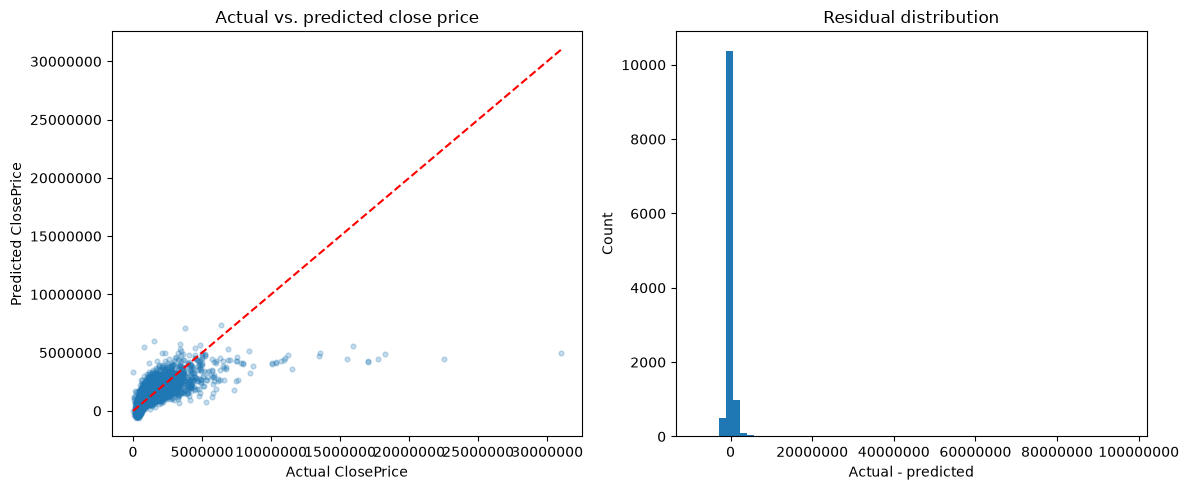

In [8]:
plot_data = prediction_diagnostics.sample(
    n=min(5_000, len(prediction_diagnostics)),
    random_state=50,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(
    plot_data["actual_close_price"],
    plot_data["predicted_close_price"],
    alpha=0.25,
    s=12,
)
price_max = max(
    plot_data["actual_close_price"].max(),
    plot_data["predicted_close_price"].max(),
)
axes[0].plot([0, price_max], [0, price_max], color="red", linestyle="--")
axes[0].set_title("Actual vs. predicted close price")
axes[0].set_xlabel("Actual ClosePrice")
axes[0].set_ylabel("Predicted ClosePrice")
axes[0].ticklabel_format(style="plain", axis="both")

axes[1].hist(prediction_diagnostics["residual"], bins=60)
axes[1].set_title("Residual distribution")
axes[1].set_xlabel("Actual - predicted")
axes[1].set_ylabel("Count")
axes[1].ticklabel_format(style="plain", axis="x")

plt.tight_layout()

## Week 4 outcome

The baseline Linear Regression model uses the 40 numeric features from Week 3 and evaluates on the May 2026 holdout month. In this run, the test R² is about 0.300. This is a useful first benchmark, but the residual spread and negative predictions show why later modeling should test target transformations, regularization, and nonlinear models.